In [ ]:
import pdfplumber
import pandas as pd

## Let's check the default OCR results

In [ ]:
pdf = pdfplumber.open("../samples/lasd-service_basic_ocr.pdf")

In [ ]:
p0 = pdf.pages[0]

In [ ]:
print(p0.extract_text())

Received Year CourtCaseNumber SheriffBranch Status ReasonNotServed DwellTime
PER RESPONDANT HAS NOT BEEN SEEN OR HEARD FROM FOR THE PAST
2024 Pomona Superior Court (North) (Los Angeles County) 24PSRO02158 NORWALK Not found WEEK. NOT AT THE LOCATION. 16
RANG DOORBELL, KNOCKED ON DOOR. NO ANSWER. MULTIPLE VEHICLES AT
2024 Pomona Superior Court (North) (Los Angeles County) 24PSRO02249 NORWALK Not found LOCATION. 5
2024 Pomona Superior Court (North) (Los Angeles County) 23PSFLO1957 PASADENA Not found PERI DEFENDANT IS UNKNOWN AT LOCATION. 1
2024 Pomona Superior Court (North) (Los Angeles County) 23PSRO02249 PASADENA Not found UNABLE TO ENTER SECURED LOCATION. SHORT DATED. 7
2024 Pomona Superior Court (North) (Los Angeles County) 24PSROOO282 PASADENA Not found __NO ANSWER AT DOOR. SHORT DATED Z 1
LOCATION IS AN APARTMENT COMPLEX. NEED INSTRUCTIONS WITH UNIT NUMBER
2024 Pomona Superior Court (North) (Los Angeles County) 24PSRO00282 PASADENA Not found TO ATTEMPTSERVICE. 1
2024 Pomona Superior

In [ ]:
p0.find_tables()

[]

Pdf Plumber relies on text and line information embeddded in the PDF to extract content. Since we OCRed our PDF, PDF plumber does not know where to look. We have to add some lines to guide the extraction.

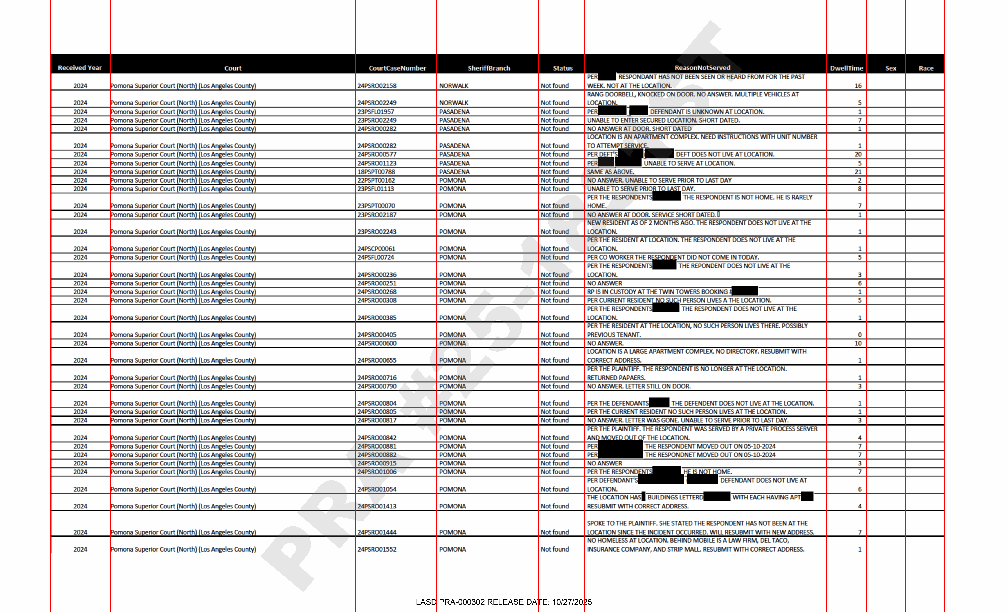

In [ ]:
p0.to_image().draw_vlines([50,110,355,436,538,584,826,866,905,944], stroke=(255,0,0), stroke_width=1)

In [ ]:
text = pd.DataFrame(p0.chars)
two_char = text.loc[text['text'] == '2'] # Find all 2s
xmin = two_char['x0'].min() # Get the left most 2 location
first_column_twos = two_char.loc[two_char['x0'] < xmin + 10] # Get all 2s in the first column (with a little buffer)
lines = first_column_twos['bottom'] # Get the bottom coordinate for each first column 2
lines_list = lines.to_list() # Convert to a list
lines_list.append(72) # Add a line for the bottom of the header

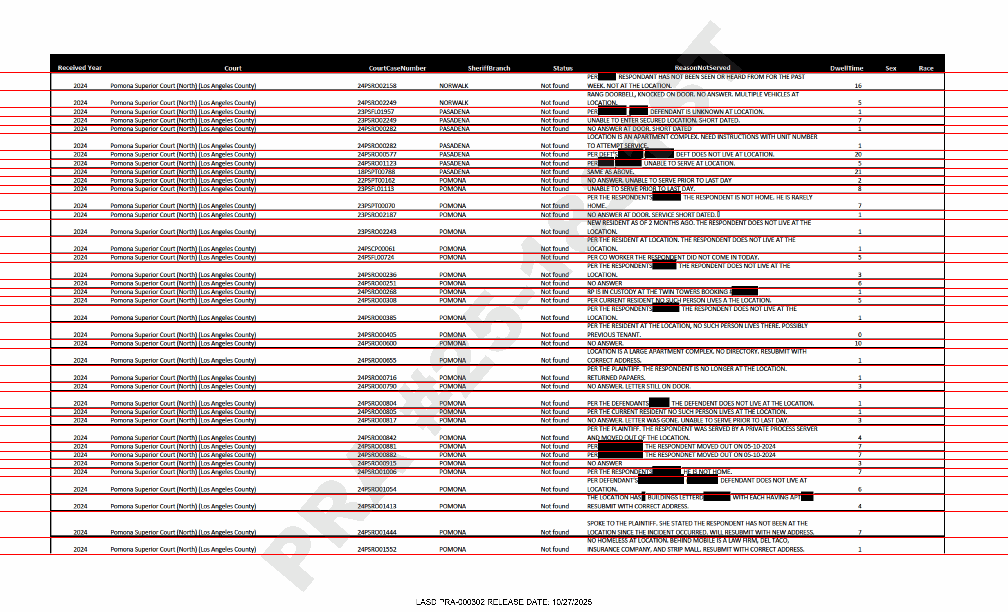

In [ ]:
p0.to_image().draw_hlines(lines_list, stroke=(255,0,0), stroke_width=1)

In [99]:
settings = {
    "explicit_horizontal_lines": lines_list,
    "explicit_vertical_lines": [50,110,355,436,538,584,826,866,905,944]
}

In [100]:
p0.find_tables(settings)

In [101]:
table_data = p0.extract_table(settings)

In [81]:
df = pd.DataFrame()

In [82]:
headers = ['received_year', 'court', 'court_case_number', 'sheriff_branch', 'status', 'reason_not_served', 'dwell_time', 'sex', 'race']

In [105]:
pd.DataFrame(table_data, columns=headers)

,received_year,court,court_case_number,sheriff_branch,status,reason_not_served,dwell_time,sex,race
0,2024,Pomona Superior Court (North) (Los Angeles Cou...,24PSRO02158,NORWALK,Not found,PER RESPONDANT HAS NOT BEEN SEEN OR HEARD FROM...,. 16,,
1,2024,Pomona Superior Court (North) (Los Angeles Cou...,24PSRO02249,NORWALK,Not found,"RANG DOORBELL, KNOCKED ON DOOR. NO ANSWER. MUL...",. 5,,
2,2024,Pomona Superior Court (North) (Los Angeles Cou...,23PSFL01957,PASADENA,Not found,PERI DEFENDANT IS UNKNOWN AT LOCATIO,N. 1,,
3,2024,Pomona Superior Court (North) (Los Angeles Cou...,23PSRO02249,PASADENA,Not found,UNABLE TO ENTER SECURED LOCATION. SHORT DATE,D. 7,,
4,2024,Pomona Superior Court (North) (Los Angeles Cou...,24PSRO00282,PASADENA,Not found __,NO ANSWER AT DOOR. SHORT DATED Z,1,,
5,2024,Pomona Superior Court (North) (Los Angeles Cou...,24PSRO00282,PASADENA,Not found,LOCATION IS AN APARTMENT COMPLEX. NEED INSTRUC...,E. 1,,
6,2024,Pomona Superior Court (North) (Los Angeles Cou...,24PSRO00577,PASADENA,Not found,"PER DEFT"" GR DET DOES Not UVE AT Locatio",n. 20,,
7,2024,Pomona Superior Court (North) (Los Angeles Cou...,24PSRO01123,PASADENA,Not found,PERI UNABLE TO SERVE AT LOCATIO,N. 5,,
8,2024,Pomona Superior Court (North) (Los Angeles Cou...,18PSPT00788,PASADENA,Not found,SAME AS ABOVE,. 21,,
9,2024,Pomona Superior Court (North) (Los Angeles Cou...,22PSPT00162,POMONA,Not found,NO ANSWER. UNABLE TO SERVE PRIOR TO LAST DA,Y 2,,


In [104]:
# for row in table_data:
#     print('\t'.join(row))

## Check the oversampled results

## Check the oversample + pattern results